<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/ARCH_GARCH_BankOfBaroda_Beginner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARCH vs GARCH Model — Bank of Baroda Case Study
---

## 1. What is a Time Series?

A **time series** is a sequence of data points collected over time,
where the order of observations matters.

**Examples:**
- Stock prices recorded daily
- Monthly inflation rates
- Quarterly GDP growth

In finance, time series analysis helps us understand how prices and
returns behave over time — and more importantly, **predict future risk.**

---

## 2. What is ARCH?

**ARCH = Autoregressive Conditional Heteroskedasticity**

Proposed by **Robert Engle (1982)** — won Nobel Prize for this!

### Simple idea:
> Volatility is not constant — **it depends on past shocks.**

### Formula:
$$\sigma^2_t = \omega + \alpha \cdot \varepsilon^2_{t-1}$$

| Term | Meaning |
|---|---|
| $\sigma^2_t$ | Today's volatility |
| $\omega$ | Base/minimum volatility |
| $\alpha$ | Impact of yesterday's shock |
| $\varepsilon^2_{t-1}$ | Yesterday's unexpected return (shock) |

### Problem with ARCH:
> It only looks at **past shocks** — but ignores that  
> **volatility itself is persistent over time.**  
> This means ARCH needs many lags to capture volatility,  
> making it inefficient.

---

## 3. What is GARCH?

**GARCH = Generalized ARCH**

Proposed by **Tim Bollerslev (1986)** — extended Engle's work.

### Simple idea:
> Volatility depends on **past shocks AND past volatility.**

### Formula:
$$\sigma^2_t = \omega + \alpha \cdot \varepsilon^2_{t-1} + \beta \cdot \sigma^2_{t-1}$$

| Term | Meaning |
|---|---|
| $\sigma^2_t$ | Today's volatility |
| $\omega$ | Base/minimum volatility |
| $\alpha$ | Impact of yesterday's shock (News Effect) |
| $\beta$ | Impact of yesterday's volatility (Persistence) |
| $\varepsilon^2_{t-1}$ | Yesterday's shock |
| $\sigma^2_{t-1}$ | Yesterday's volatility |

---

## 4. ARCH vs GARCH — Key Differences

| Feature | ARCH | GARCH |
|---|---|---|
| Proposed by | Engle (1982) | Bollerslev (1986) |
| Looks at | Past shocks only | Past shocks + Past volatility |
| Formula | $\omega + \alpha\varepsilon^2_{t-1}$ | $\omega + \alpha\varepsilon^2_{t-1} + \beta\sigma^2_{t-1}$ |
| Parameters | Few | More (but efficient) |
| Lags needed | Many | Few |
| Used in practice | Rarely | Very commonly |
| Captures persistence | ❌ No | ✅ Yes |

---

## 5. Why GARCH over ARCH?

**1. Volatility Clustering:**
> In real markets, large moves tend to be followed by large moves.  
> GARCH captures this through the $\beta$ (persistence) term.

**2. Fewer Parameters:**
> ARCH needs many lags to fit well.  
> GARCH(1,1) with just 3 parameters does the job better.

**3. Better Fit:**
> GARCH consistently shows lower AIC/BIC scores —  
> meaning it explains data better with less complexity.

**4. Real World Evidence:**
> For most financial assets: $\alpha + \beta$ is close to 1,  
> meaning volatility is highly persistent —  
> something only GARCH can capture efficiently.

---

## 6. Case Study — Bank of Baroda (BOB)

Now that we understand the theory, let us apply both models  
on **real stock data of Bank of Baroda (BOB.NS)**  
and compare their performance.

We will:
- Download historical stock data
- Compute daily returns
- Test for ARCH effects
- Fit ARCH and GARCH models
- Compare results and interpret parameters

> *"Theory makes sense — but data tells the real story."*

---

# ARCH vs GARCH — Bank of Baroda Stock
### A Beginner-Friendly, Step-by-Step Guide with Explanations

---

## What Are We Trying To Do?

When you watch Bank of Baroda's share price, you notice:
- Some weeks are calm — small daily moves
- Some weeks are wild — big daily swings

This "wildness" is called **volatility**. And here is the key insight:

> **Calm days tend to be followed by calm days. Wild days tend to be followed by wild days.**

This is called **volatility clustering** — and it's the reason ARCH/GARCH models exist.

| Model | What it says |
|-------|-------------|
| **ARCH** | Today's volatility = function of **past shocks only** |
| **GARCH** | Today's volatility = function of **past shocks + past volatility** |

Think of it this way:
- ARCH has a **short memory** — only remembers recent big moves
- GARCH has a **long memory** — remembers both recent moves AND how volatile things have generally been

---
**Stock**: Bank of Baroda (`BANKBARODA.NS`) | **Period**: 1 Year | **Source**: Yahoo Finance

---
## Step 1: Install Libraries

We need two libraries that are not pre-installed in Google Colab:
- **yfinance** — downloads real stock price data from Yahoo Finance for free
- **arch** — fits ARCH and GARCH volatility models

In [1]:
# The ! tells Colab to run this as a system command, not Python
# pip install = download and install the package
# --quiet = suppress the installation output clutter
!pip install yfinance arch --quiet

print('Done! Libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.9 MB/s eta 0:00:00
Done! Libraries installed.


---
## Step 2: Import All Tools

Think of imports like picking up your tools before starting work.

In [2]:
import numpy as np            # Math: square root, log, etc.
import pandas as pd           # Tables of data (like Excel in Python)
import matplotlib.pyplot as plt   # Drawing charts
import matplotlib.dates as mdates # Formatting dates on chart axes
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm  # Normal distribution curve

import yfinance as yf         # Download real stock data

# Statistical tests we will use
from statsmodels.tsa.stattools import adfuller       # ADF stationarity test
from statsmodels.stats.diagnostic import acorr_ljungbox  # Ljung-Box test
from statsmodels.graphics.tsaplots import plot_acf   # Autocorrelation plot

from arch import arch_model   # The ARCH/GARCH model library

# Default chart size for all plots
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All tools ready!')

All tools ready!


---
## Step 3: Download Bank of Baroda Data

Yahoo Finance identifies each stock with a **ticker symbol**.
`.NS` at the end means the stock is on the **NSE (National Stock Exchange)**.

We download 1 year of daily closing prices.

In [3]:
TICKER     = 'BANKBARODA.NS'   # Bank of Baroda on NSE
ASSET_NAME = 'Bank of Baroda'

# Calculate date range
# pd.Timestamp.today() = today's date
# .strftime('%Y-%m-%d') = format as 'YYYY-MM-DD' string
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')
START_DATE = (pd.Timestamp.today() - pd.DateOffset(years=1)).strftime('%Y-%m-%d')

print(f'Downloading {ASSET_NAME}  ({START_DATE} to {END_DATE})...')

# yf.download() fetches data from Yahoo Finance
# auto_adjust=True adjusts for dividends and stock splits automatically
raw_data = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# Keep only the closing price column
df = raw_data[['Close']].copy()
df.columns = ['Close']
df.dropna(inplace=True)  # Remove any rows with missing data

print(f'Downloaded {len(df)} trading days')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 247 trading days
Date range: 2025-03-24 to 2026-03-20


,Close
Date,
2025-03-24,216.991852
2025-03-25,215.638489
2025-03-26,212.999435
2025-03-27,223.284958
2025-03-28,220.916595


---
## Step 4: Explore the Data — Plot the Stock Price

Always visualize data before any analysis. Get a feel for what the stock did over the year.

Bank of Baroda — Price Summary
--------------------------------------
Starting Price : Rs.216.99
Ending Price   : Rs.279.95
Lowest Price   : Rs.210.03
Highest Price  : Rs.324.45
1-Year Return  : 29.01%


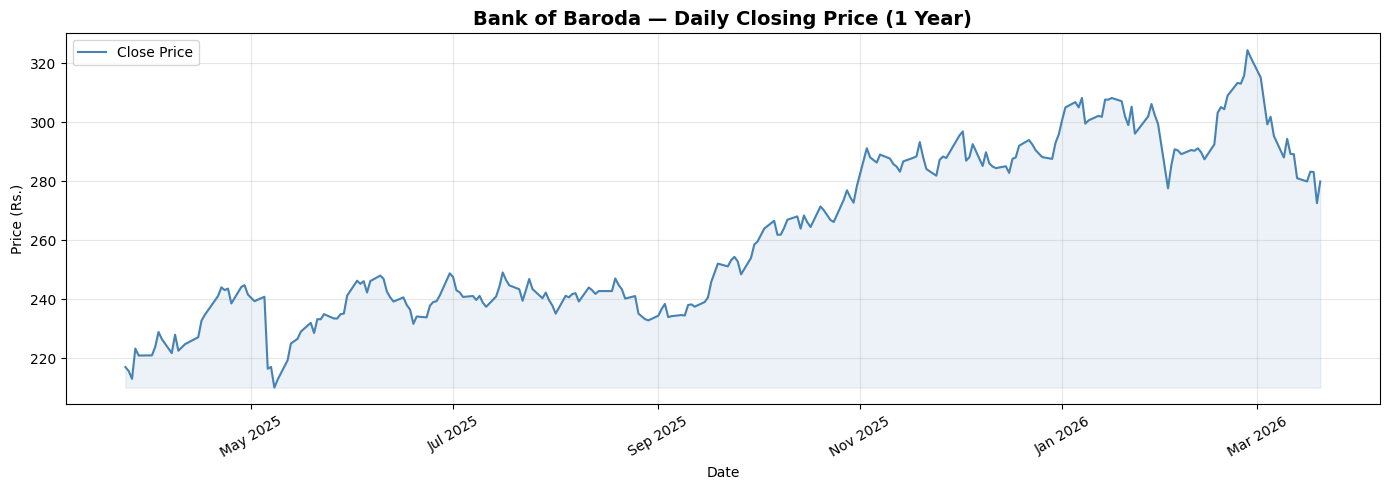

In [4]:
# Basic stats
print(f'{ASSET_NAME} — Price Summary')
print('-' * 38)
print(f'Starting Price : Rs.{df["Close"].iloc[0]:.2f}')
print(f'Ending Price   : Rs.{df["Close"].iloc[-1]:.2f}')
print(f'Lowest Price   : Rs.{df["Close"].min():.2f}')
print(f'Highest Price  : Rs.{df["Close"].max():.2f}')
yearly_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
print(f'1-Year Return  : {yearly_return:.2f}%')

# fig = the canvas | ax = the plot area
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.5, label='Close Price')
ax.fill_between(df.index, df['Close'], df['Close'].min(), alpha=0.1, color='steelblue')

ax.set_title(f'{ASSET_NAME} — Daily Closing Price (1 Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (Rs.)')
ax.legend()

# Format x-axis to show month and year like 'Mar 2024'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Step 5: Compute Log Returns

### Why can't we use raw prices directly?

ARCH/GARCH needs **stationary** data — data that fluctuates around a fixed average, not data that drifts up or down. Raw stock prices always drift, so we cannot use them directly.

We use **log returns** — the day-to-day percentage change:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) \times 100$$

Example: Price goes from Rs.200 to Rs.202
$$r_t = \ln\left(\frac{202}{200}\right) \times 100 \approx +1.0\%$$

In [5]:
# np.log() = natural logarithm
# .shift(1) = yesterday's price (shifts the column down by one row)
# Multiply by 100 = express as a percentage
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 100

# The first row becomes NaN (no previous price to compare), so drop it
df.dropna(inplace=True)
returns = df['Log_Return']  # Shortcut for convenience

print('Log Returns — Key Statistics')
print('-' * 42)
print(f'Observations    : {len(returns)}')
print(f'Average return  : {returns.mean():.4f}%  (close to zero = good for modeling)')
print(f'Std deviation   : {returns.std():.4f}%   (typical daily swing)')
print(f'Best single day : +{returns.max():.4f}%')
print(f'Worst single day: {returns.min():.4f}%')
print(f'Kurtosis        : {returns.kurt():.4f}')
print()
print('What does Kurtosis tell us?')
print('  A normal distribution has kurtosis = 0 (in excess kurtosis terms).')
k = returns.kurt()
if k > 1:
    print(f'  This stock has kurtosis = {k:.2f} (much higher than 0)')
    print('  This means FAT TAILS — extreme daily moves happen more often')
    print('  than a normal distribution would predict. This is why we need ARCH/GARCH!')

Log Returns — Key Statistics
------------------------------------------
Observations    : 246
Average return  : 0.1036%  (close to zero = good for modeling)
Std deviation   : 1.6915%   (typical daily swing)
Best single day : +4.7159%
Worst single day: -10.6731%
Kurtosis        : 7.6652

What does Kurtosis tell us?
  A normal distribution has kurtosis = 0 (in excess kurtosis terms).
  This stock has kurtosis = 7.67 (much higher than 0)
  This means FAT TAILS — extreme daily moves happen more often
  than a normal distribution would predict. This is why we need ARCH/GARCH!


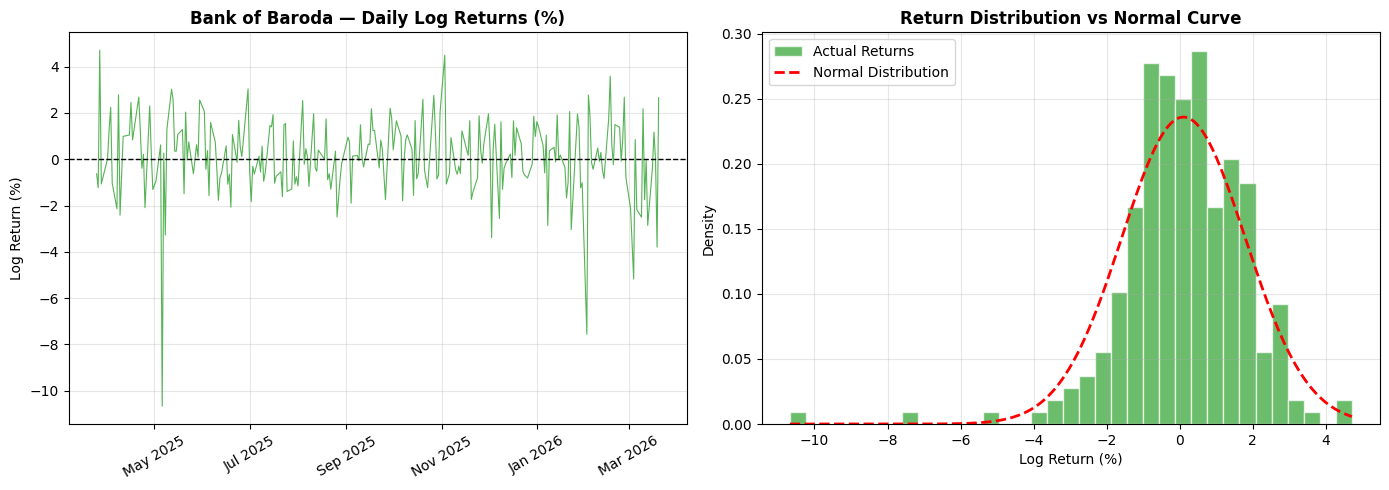

The green distribution has a TALLER peak and FATTER tails than the red normal curve.
This is typical for stocks — called leptokurtosis.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Returns over time
axes[0].plot(returns.index, returns.values, color='#2ca02c', linewidth=0.8, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')  # zero line
axes[0].set_title(f'{ASSET_NAME} — Daily Log Returns (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Return (%)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# RIGHT: Distribution of returns compared to normal distribution
# bins=35 means divide the range into 35 bars
# density=True normalizes so area under histogram = 1
axes[1].hist(returns, bins=35, color='#2ca02c', alpha=0.7,
             edgecolor='white', density=True, label='Actual Returns')
x = np.linspace(returns.min(), returns.max(), 200)
axes[1].plot(x, norm.pdf(x, returns.mean(), returns.std()),
             'r--', linewidth=2, label='Normal Distribution')
axes[1].set_title('Return Distribution vs Normal Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log Return (%)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print('The green distribution has a TALLER peak and FATTER tails than the red normal curve.')
print('This is typical for stocks — called leptokurtosis.')

---
## Step 6: Stationarity Test (ADF Test)

### What is stationarity?
A series is **stationary** if its average and spread don't change over time — it wiggles around a fixed center rather than drifting.

- Raw stock price → drifts up/down → **NOT stationary**
- Log returns → fluctuate around zero → **Stationary**

**Rule for ADF test**: p-value < 0.05 → series is stationary

In [7]:
def run_adf_test(series, label):
    """
    Augmented Dickey-Fuller test for stationarity.
    If p-value < 0.05 -> stationary -> safe to use in ARCH/GARCH.
    """
    # adfuller() returns: (test_stat, p_value, lags_used, n_obs, critical_values, ...)
    result = adfuller(series.dropna(), autolag='AIC')

    print(f'ADF Test on: {label}')
    print('-' * 45)
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.6f}')
    print(f'Critical values:')
    for level, val in result[4].items():
        print(f'   {level} : {val:.4f}')

    if result[1] < 0.05:
        print('RESULT: STATIONARY (p < 0.05 -- safe to use in models)')
    else:
        print('RESULT: NOT STATIONARY (p >= 0.05 -- needs differencing)')
    print()


run_adf_test(df['Close'], 'Raw Closing Price')
run_adf_test(returns, 'Log Returns')

ADF Test on: Raw Closing Price
---------------------------------------------
ADF Statistic : -1.7096
p-value       : 0.426187
Critical values:
   1% : -3.4573
   5% : -2.8734
   10% : -2.5731
RESULT: NOT STATIONARY (p >= 0.05 -- needs differencing)

ADF Test on: Log Returns
---------------------------------------------
ADF Statistic : -16.3579
p-value       : 0.000000
Critical values:
   1% : -3.4573
   5% : -2.8734
   10% : -2.5731
RESULT: STATIONARY (p < 0.05 -- safe to use in models)



---
## Step 7: See the Volatility Clustering

This is the most important chart to understand before fitting any model.
Look carefully at the bottom panel — you should see the red line go HIGH during turbulent periods and stay LOW during calm periods in bunches.

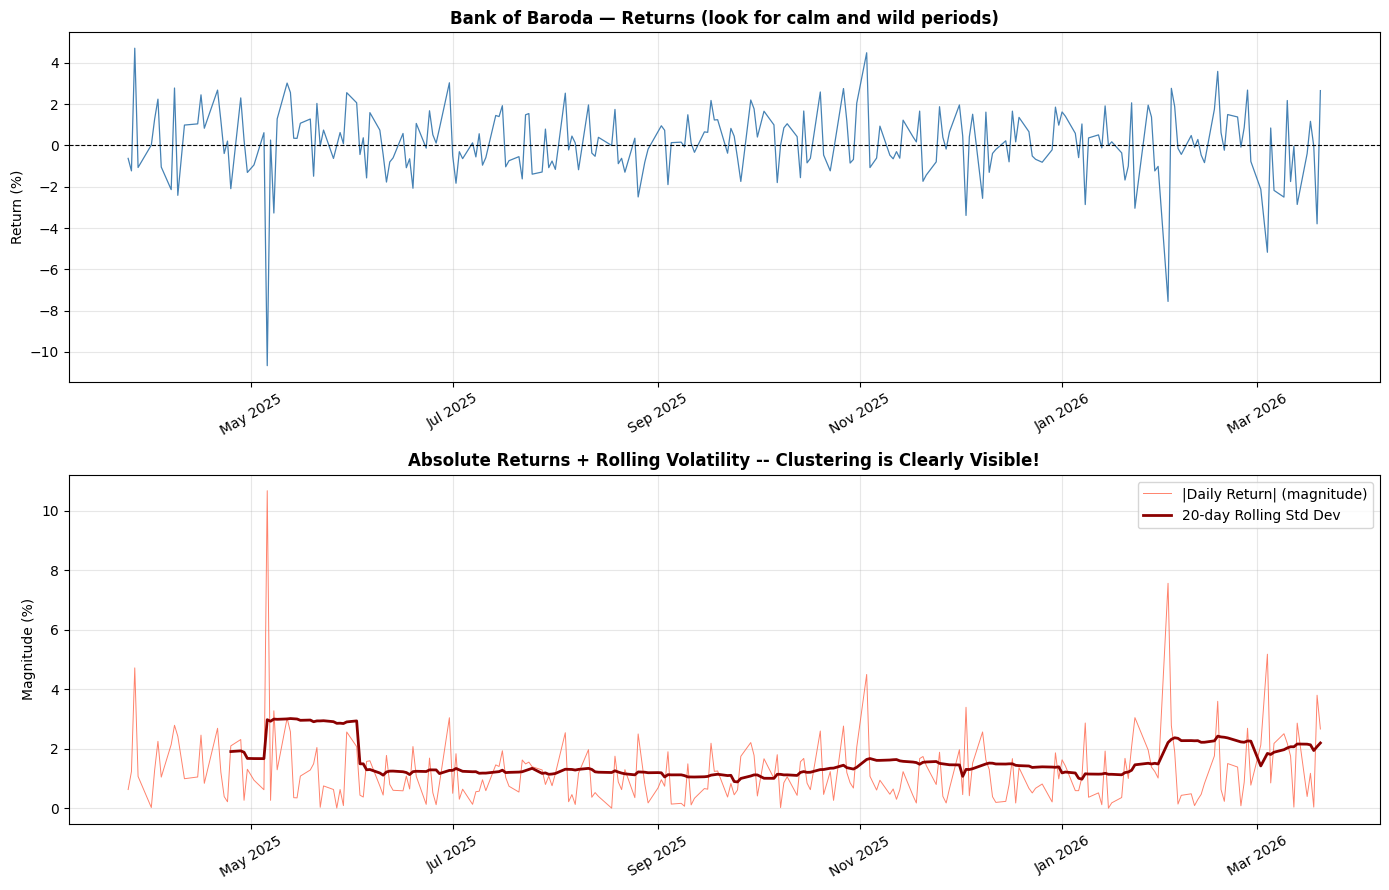

Key observation:
  The dark red line rises and falls in chunks (not randomly).
  This clustering pattern is EXACTLY what ARCH/GARCH models.


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# TOP: The actual returns
axes[0].plot(returns.index, returns.values, color='steelblue', linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'{ASSET_NAME} — Returns (look for calm and wild periods)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)')

# BOTTOM: Absolute value of returns + rolling standard deviation
# |return| = how big the move was (ignore direction, just magnitude)
axes[1].plot(returns.index, returns.abs().values,
             color='tomato', linewidth=0.7, alpha=0.8, label='|Daily Return| (magnitude)')

# Rolling std = the standard deviation over the past 20 trading days
# This is a simple moving-average measure of how volatile things have been
rolling_vol = returns.rolling(window=20).std()
axes[1].plot(returns.index, rolling_vol.values,
             color='darkred', linewidth=2, label='20-day Rolling Std Dev')

axes[1].set_title('Absolute Returns + Rolling Volatility -- Clustering is Clearly Visible!',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Magnitude (%)')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print('Key observation:')
print('  The dark red line rises and falls in chunks (not randomly).')
print('  This clustering pattern is EXACTLY what ARCH/GARCH models.')

---
## Step 8: Statistically Confirm ARCH Effects (Ljung-Box Test)

Visually we see clustering. Now we confirm it statistically.

**The idea:**
1. Square the returns (r²) to emphasize large moves
2. Ask: are today's r² correlated with yesterday's r²?
3. If YES → volatility clusters → ARCH/GARCH is the right tool

**Ljung-Box rule:** p-value < 0.05 → correlation exists → ARCH effect confirmed

In [9]:
# Demean the returns to get residuals (remove the tiny average)
residuals     = returns - returns.mean()
squared_resid = residuals ** 2   # Square them to focus on magnitude

# Ljung-Box test at lags 5, 10, 15
# lag=5 means: does today's squared return correlate with 5 days ago?
lb_result = acorr_ljungbox(squared_resid, lags=[5, 10, 15], return_df=True)

print('Ljung-Box Test on SQUARED Returns')
print('Testing: are big days clustered with previous big days?')
print('-' * 55)
print(lb_result.round(4))
print()

if (lb_result['lb_pvalue'] < 0.05).any():
    print('RESULT: p < 0.05 found!')
    print('ARCH EFFECTS CONFIRMED -- modeling volatility with ARCH/GARCH is justified.')
else:
    print('No ARCH effects found.')

Ljung-Box Test on SQUARED Returns
Testing: are big days clustered with previous big days?
-------------------------------------------------------
    lb_stat  lb_pvalue
5    1.4119     0.9230
10   2.0972     0.9955
15   2.8600     0.9997

No ARCH effects found.


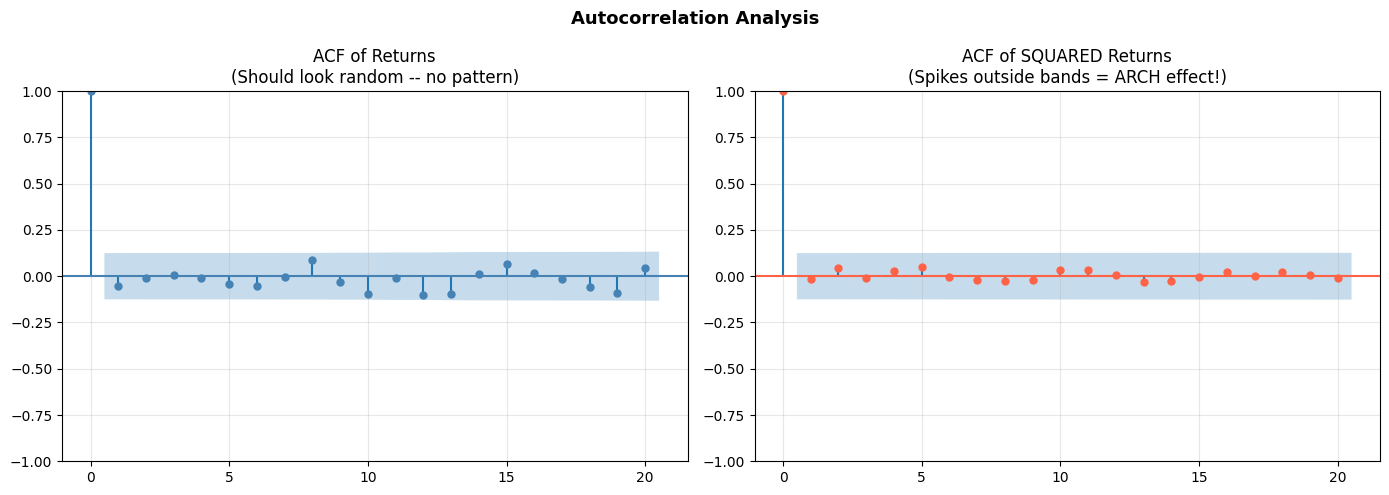

Even if returns (left) look random, their SQUARES (right) show clear patterns.
This is the hallmark of volatility clustering.


In [10]:
# Visual ACF plot
# ACF = AutoCorrelation Function
# Shows: how correlated is the series with its own past values?
# Blue dashed lines = 95% confidence bands
# Spikes outside the bands = statistically significant correlation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(returns, lags=20, ax=axes[0],
         title='ACF of Returns\n(Should look random -- no pattern)', color='steelblue')

plot_acf(squared_resid, lags=20, ax=axes[1],
         title='ACF of SQUARED Returns\n(Spikes outside bands = ARCH effect!)', color='tomato')

plt.suptitle('Autocorrelation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Even if returns (left) look random, their SQUARES (right) show clear patterns.')
print('This is the hallmark of volatility clustering.')

---
## Step 9: Fit the ARCH Model

### How ARCH works

ARCH says: *"My estimate of today's volatility is based on how big the recent surprises were."*

**ARCH(5) formula — looking back 5 days:**

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \alpha_2 \epsilon_{t-2}^2 + \alpha_3 \epsilon_{t-3}^2 + \alpha_4 \epsilon_{t-4}^2 + \alpha_5 \epsilon_{t-5}^2$$

| Symbol | Meaning |
|--------|---------|
| $\sigma_t^2$ | Today's variance (volatility squared) |
| $\omega$ | Baseline variance — always-present level of uncertainty |
| $\alpha_i$ | Weight given to the shock from i days ago |
| $\epsilon_{t-i}^2$ | Squared return from i days ago (the past "surprise") |

In [11]:
print('Fitting ARCH(5) Model...')

# arch_model() SETS UP the model structure — does NOT fit yet
#   vol='ARCH'      : use the ARCH variance specification
#   p=5             : look back 5 days of squared errors
#   mean='Constant' : assume returns have a constant mean
#   dist='normal'   : assume innovations are normally distributed
arch_mod = arch_model(
    returns,
    vol='ARCH',
    p=5,
    mean='Constant',
    dist='normal'
)

# .fit() estimates the best parameter values
# disp='off' = suppress the per-iteration output
arch_result = arch_mod.fit(disp='off')

print(arch_result.summary())

Fitting ARCH(5) Model...
                      Constant Mean - ARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -470.213
Distribution:                  Normal   AIC:                           954.427
Method:            Maximum Likelihood   BIC:                           978.964
                                        No. Observations:                  246
Date:                Mon, Mar 23 2026   Df Residuals:                      245
Time:                        03:55:54   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0906      0.117      0.777  

In [12]:
print('ARCH(5) Parameters -- Plain English')
print('=' * 52)

arch_params = arch_result.params
print(f"omega = {arch_params['omega']:.6f}")
print(f"  This is the baseline variance (a floor that always exists)")
print()

total_alpha = 0
for i in range(1, 6):
    val = arch_params[f'alpha[{i}]']
    total_alpha += val
    print(f"alpha[{i}] = {val:.4f}  -- weight of shock from {i} day(s) ago")

print(f'\nSum of alphas = {total_alpha:.4f}')
print('Sum < 1 means model is STABLE (volatility will eventually calm down)' if total_alpha < 1 else 'Warning: sum >= 1')

print(f'\nAIC = {arch_result.aic:.3f}  |  BIC = {arch_result.bic:.3f}')
print('(We will compare these to GARCH later -- lower = better fit)')

ARCH(5) Parameters -- Plain English
omega = 1.868782
  This is the baseline variance (a floor that always exists)

alpha[1] = 0.0000  -- weight of shock from 1 day(s) ago
alpha[2] = 0.0146  -- weight of shock from 2 day(s) ago
alpha[3] = 0.0000  -- weight of shock from 3 day(s) ago
alpha[4] = 0.0305  -- weight of shock from 4 day(s) ago
alpha[5] = 0.3722  -- weight of shock from 5 day(s) ago

Sum of alphas = 0.4172
Sum < 1 means model is STABLE (volatility will eventually calm down)

AIC = 954.427  |  BIC = 978.964
(We will compare these to GARCH later -- lower = better fit)


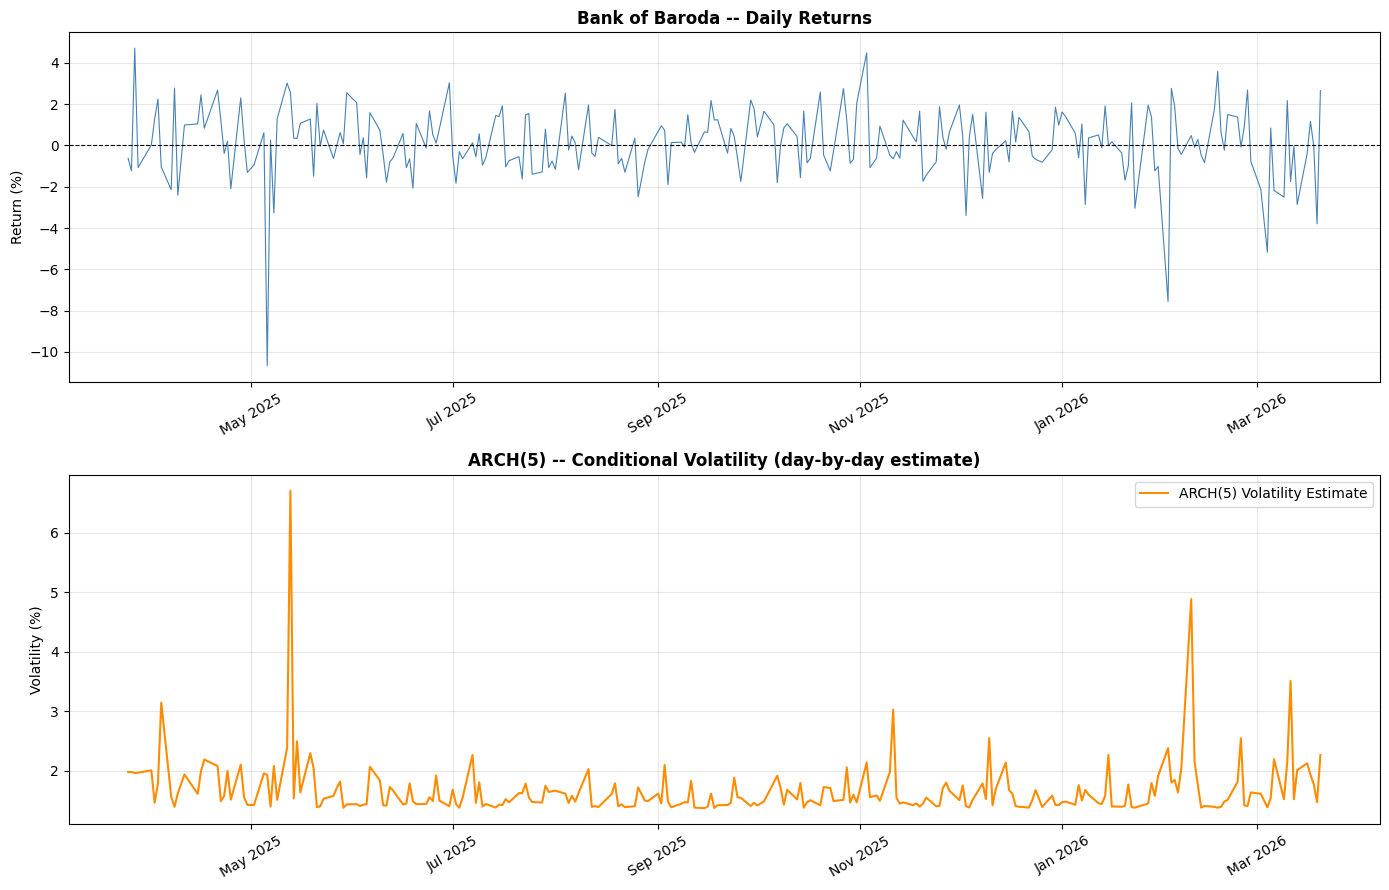

ARCH volatility spikes sharply when big moves happen (top chart).
It can look jagged -- because ARCH only remembers recent shocks, not general trend.


In [13]:
# conditional_volatility = the model's day-by-day volatility estimate
arch_vol = arch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Top: Returns
axes[0].plot(returns.index, returns.values, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'{ASSET_NAME} -- Daily Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)')

# Bottom: ARCH estimated volatility
axes[1].plot(arch_vol.index, arch_vol.values,
             color='darkorange', linewidth=1.5, label='ARCH(5) Volatility Estimate')
axes[1].set_title('ARCH(5) -- Conditional Volatility (day-by-day estimate)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print('ARCH volatility spikes sharply when big moves happen (top chart).')
print('It can look jagged -- because ARCH only remembers recent shocks, not general trend.')

---
## Step 10: Fit the GARCH Model

### How GARCH improves on ARCH

GARCH adds a crucial ingredient — it also considers **how volatile things have been**, not just recent big moves.

**GARCH(1,1) formula:**

$$\sigma_t^2 = \underbrace{\omega}_{\text{baseline}} + \underbrace{\alpha \cdot \epsilon_{t-1}^2}_{\text{yesterday's shock}} + \underbrace{\beta \cdot \sigma_{t-1}^2}_{\text{yesterday's volatility}}$$

The beta term is the key difference:
- If beta = 0.90 → yesterday's volatility still explains 90% of today's
- Markets stay "nervous" for a while after a shock — beta captures this

**GARCH(1,1) needs only 3 parameters** yet captures what ARCH(5) needs 6+ for!

In [14]:
print('Fitting GARCH(1,1) Model...')

# vol='GARCH' : use the GARCH variance specification
# p=1         : 1 GARCH lag (how many past variances to use)
# q=1         : 1 ARCH lag (how many past squared shocks to use)
# GARCH(1,1) is almost always enough for financial data
garch_mod = arch_model(
    returns,
    vol='GARCH',
    p=1,
    q=1,
    mean='Constant',
    dist='normal'
)

garch_result = garch_mod.fit(disp='off')
print(garch_result.summary())

Fitting GARCH(1,1) Model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -473.519
Distribution:                  Normal   AIC:                           955.038
Method:            Maximum Likelihood   BIC:                           969.059
                                        No. Observations:                  246
Date:                Mon, Mar 23 2026   Df Residuals:                      245
Time:                        03:57:45   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0944      0.103      0.91

In [15]:
params = garch_result.params
omega = params['omega']
alpha = params['alpha[1]']
beta  = params['beta[1]']

print('GARCH(1,1) Parameters -- Plain English')
print('=' * 55)
print(f'omega = {omega:.6f}')
print(f'  The minimum baseline variance (the floor level)')
print()
print(f'alpha = {alpha:.4f}')
print(f'  How strongly a big move TODAY affects TOMORROW\'s volatility')
print(f'  Interpretation: each shock has a {alpha*100:.1f}% immediate impact')
print()
print(f'beta  = {beta:.4f}')
print(f'  How much of yesterday\'s volatility carries over to today')
print(f'  Interpretation: {beta*100:.1f}% of volatility persists day to day')
print()
print(f'alpha + beta = {alpha + beta:.4f}')

if alpha + beta < 1:
    print('Stationarity condition satisfied (alpha + beta < 1)')
    half_life = np.log(0.5) / np.log(alpha + beta)
    long_run_vol = np.sqrt(omega / (1 - alpha - beta))
    print(f'\nVolatility half-life: {half_life:.1f} trading days')
    print(f'  After a shock, volatility drops by half in about {half_life:.0f} days')
    print(f'Long-run daily volatility: {long_run_vol:.4f}%')
    print(f'  On a calm day, this is the typical expected swing')

print(f'\nAIC = {garch_result.aic:.3f}  |  BIC = {garch_result.bic:.3f}')

GARCH(1,1) Parameters -- Plain English
omega = 0.080283
  The minimum baseline variance (the floor level)

alpha = 0.0048
  How strongly a big move TODAY affects TOMORROW's volatility
  Interpretation: each shock has a 0.5% immediate impact

beta  = 0.9620
  How much of yesterday's volatility carries over to today
  Interpretation: 96.2% of volatility persists day to day

alpha + beta = 0.9668
Stationarity condition satisfied (alpha + beta < 1)

Volatility half-life: 20.5 trading days
  After a shock, volatility drops by half in about 21 days
Long-run daily volatility: 1.5552%
  On a calm day, this is the typical expected swing

AIC = 955.038  |  BIC = 969.059


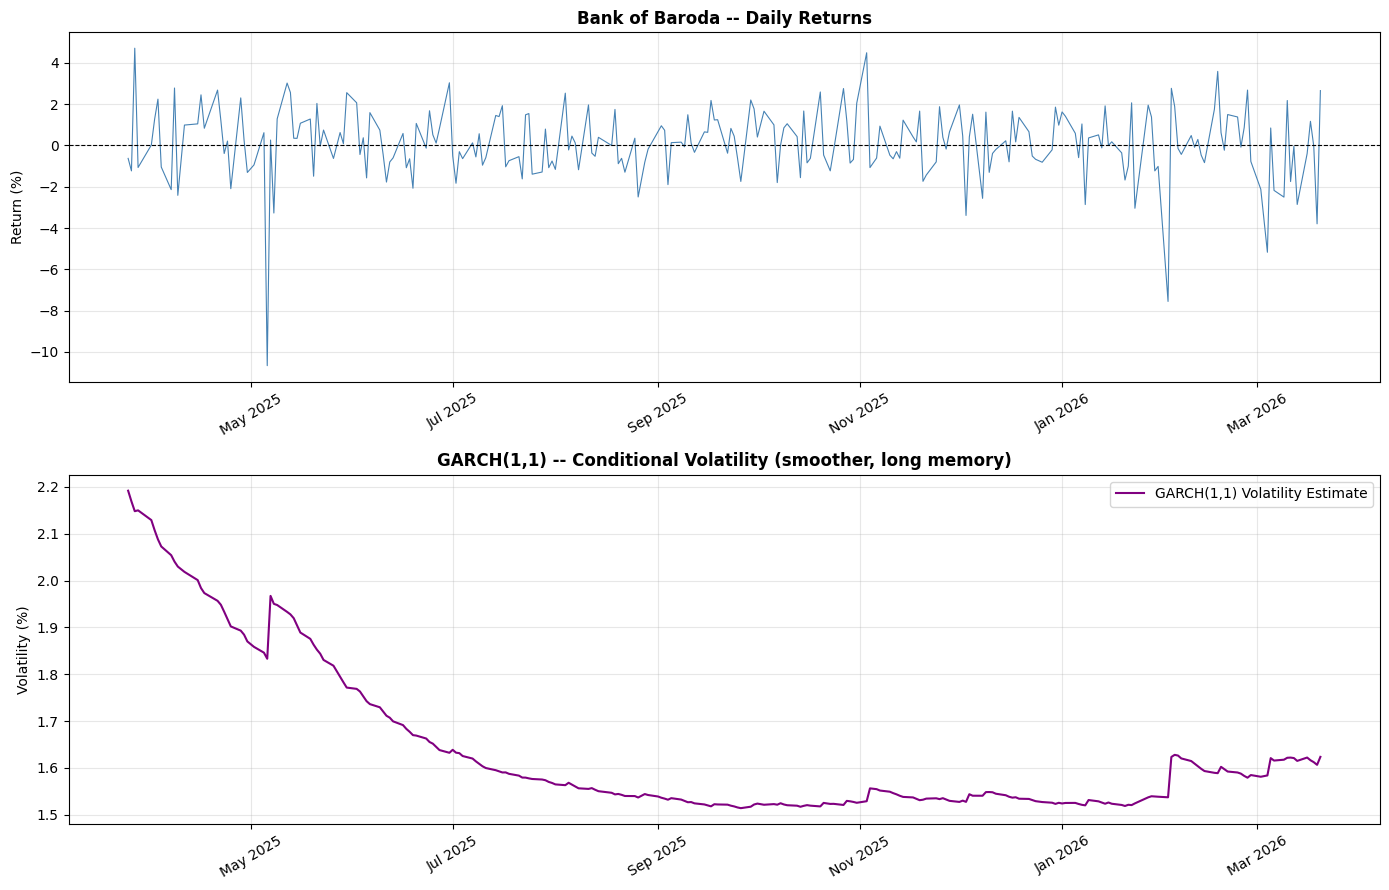

Compare to the ARCH chart above. GARCH is SMOOTHER.
It rises and falls gradually because it also tracks the general volatility level.


In [16]:
garch_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(returns.index, returns.values, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'{ASSET_NAME} -- Daily Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)')

axes[1].plot(garch_vol.index, garch_vol.values,
             color='purple', linewidth=1.5, label='GARCH(1,1) Volatility Estimate')
axes[1].set_title('GARCH(1,1) -- Conditional Volatility (smoother, long memory)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print('Compare to the ARCH chart above. GARCH is SMOOTHER.')
print('It rises and falls gradually because it also tracks the general volatility level.')

---
## Step 11: Direct Comparison — ARCH vs GARCH

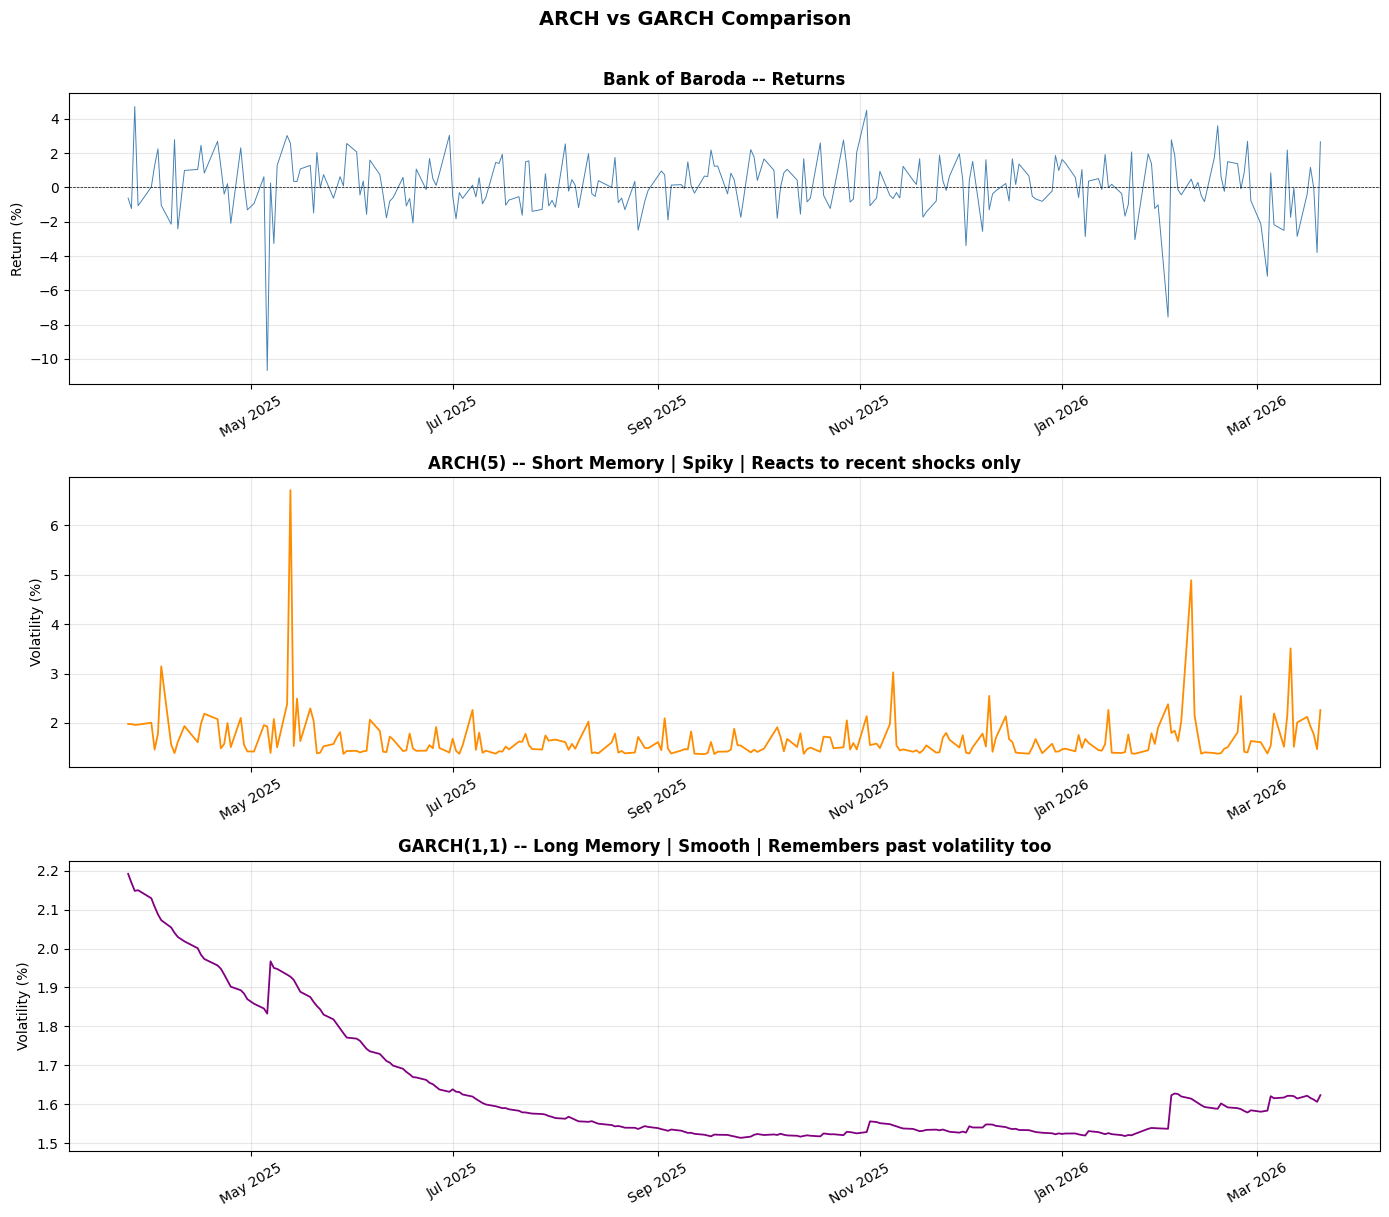

In [17]:
# Three-panel side-by-side
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(returns.index, returns.values, color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f'{ASSET_NAME} -- Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)')

axes[1].plot(arch_vol.index, arch_vol.values, color='darkorange', linewidth=1.3)
axes[1].set_title('ARCH(5) -- Short Memory | Spiky | Reacts to recent shocks only',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')

axes[2].plot(garch_vol.index, garch_vol.values, color='purple', linewidth=1.3)
axes[2].set_title('GARCH(1,1) -- Long Memory | Smooth | Remembers past volatility too',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Volatility (%)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('ARCH vs GARCH Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

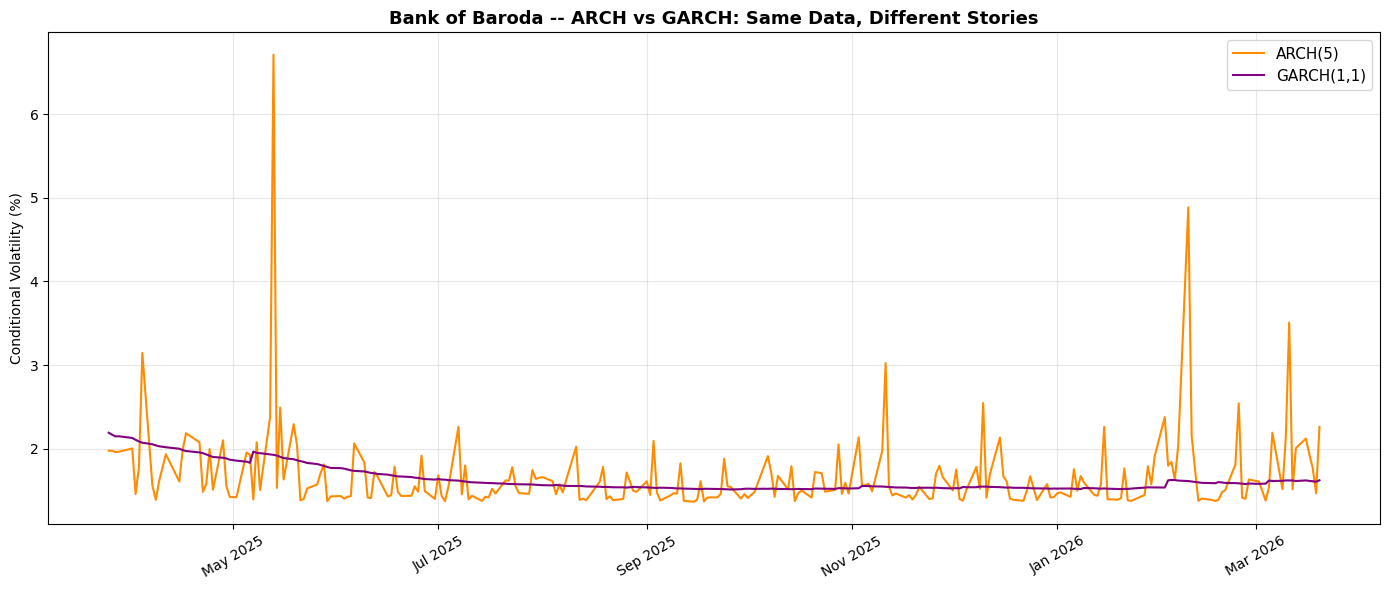

Model Comparison
Metric                               ARCH(5)    GARCH(1,1)
----------------------------------------------------------
Number of parameters                       7             4
Log-Likelihood                      -470.213      -473.519
AIC                                  954.427       955.038
BIC                                  978.964       969.059
Mean volatility                       1.6778        1.6365

Lower AIC/BIC = better model. Higher Log-Likelihood = better model.
Winner by AIC: ARCH(5)
(GARCH almost always wins because it captures more with fewer parameters)


In [18]:
# Overlay both on the same chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(arch_vol.index,  arch_vol.values,  color='darkorange', linewidth=1.5, label='ARCH(5)')
ax.plot(garch_vol.index, garch_vol.values, color='purple',     linewidth=1.5, label='GARCH(1,1)')
ax.set_title(f'{ASSET_NAME} -- ARCH vs GARCH: Same Data, Different Stories',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Conditional Volatility (%)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Numbers side by side
print('Model Comparison')
print('=' * 58)
print(f'{"Metric":<30} {"ARCH(5)":>13} {"GARCH(1,1)":>13}')
print('-' * 58)
print(f'{"Number of parameters":<30} {"7":>13} {"4":>13}')
print(f'{"Log-Likelihood":<30} {arch_result.loglikelihood:>13.3f} {garch_result.loglikelihood:>13.3f}')
print(f'{"AIC":<30} {arch_result.aic:>13.3f} {garch_result.aic:>13.3f}')
print(f'{"BIC":<30} {arch_result.bic:>13.3f} {garch_result.bic:>13.3f}')
print(f'{"Mean volatility":<30} {arch_vol.mean():>13.4f} {garch_vol.mean():>13.4f}')
print('=' * 58)

print()
print('Lower AIC/BIC = better model. Higher Log-Likelihood = better model.')
winner = 'GARCH(1,1)' if garch_result.aic < arch_result.aic else 'ARCH(5)'
print(f'Winner by AIC: {winner}')
print('(GARCH almost always wins because it captures more with fewer parameters)')

---
## Step 12: Check Model Quality — Residual Diagnostics

### How to know if the model worked?

After fitting, look at what the model **could not explain** — the residuals.

A good model leaves behind residuals that:
- Look like random noise (no more patterns)
- Have no remaining ARCH effects

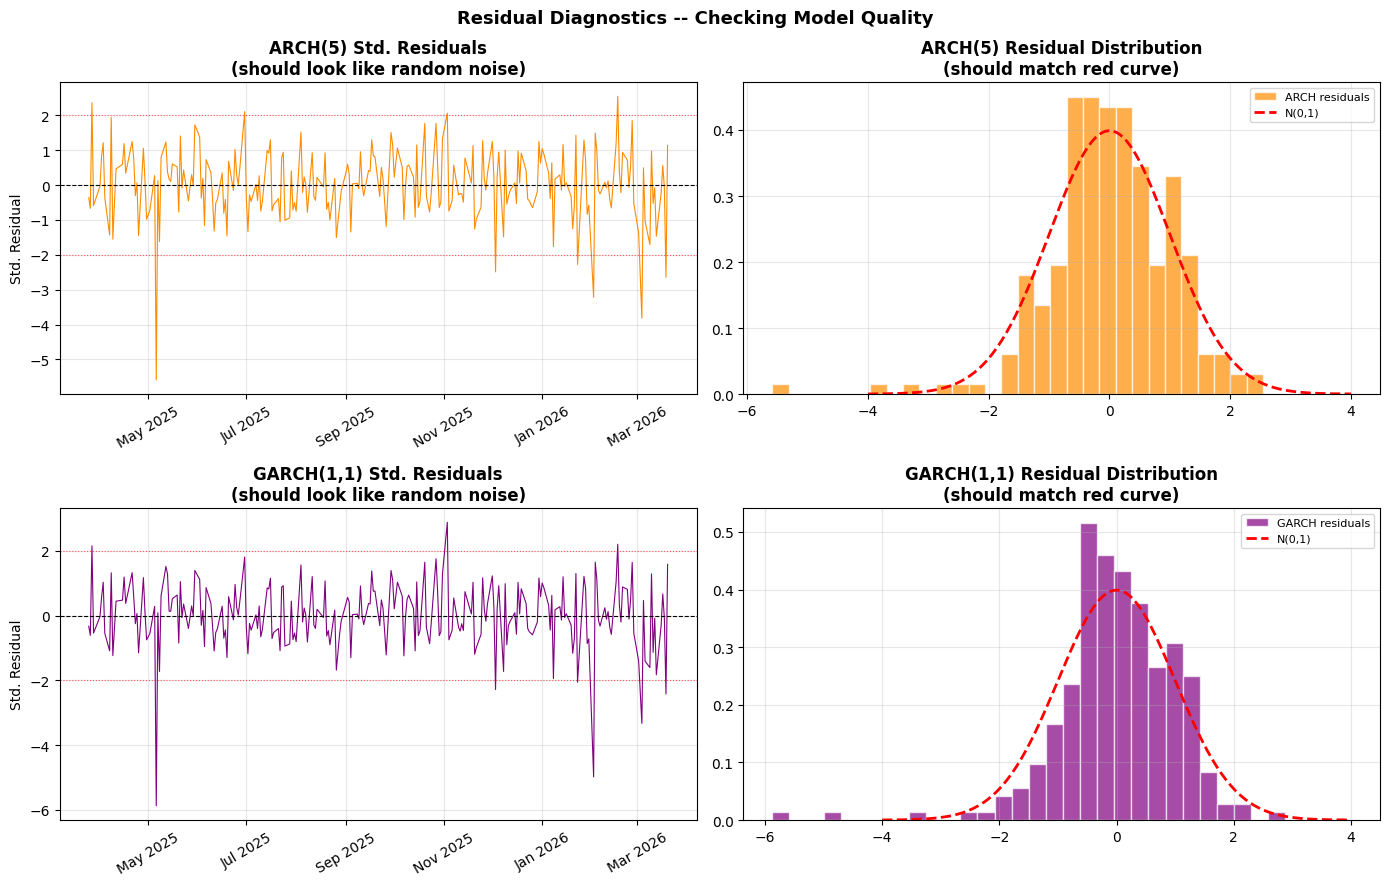

In [19]:
# std_resid = (actual return - predicted mean) / estimated daily volatility
# If model is correct, these should look like random N(0,1) draws
arch_std_resid  = arch_result.std_resid
garch_std_resid = garch_result.std_resid

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(arch_std_resid.index, arch_std_resid.values, color='darkorange', linewidth=0.8)
axes[0,0].axhline(0,  color='black', linewidth=0.8, linestyle='--')
axes[0,0].axhline(2,  color='red',   linewidth=0.8, linestyle=':', alpha=0.6)
axes[0,0].axhline(-2, color='red',   linewidth=0.8, linestyle=':', alpha=0.6)
axes[0,0].set_title('ARCH(5) Std. Residuals\n(should look like random noise)', fontweight='bold')
axes[0,0].set_ylabel('Std. Residual')

x_range = np.linspace(-4, 4, 200)
axes[0,1].hist(arch_std_resid.dropna(), bins=30, color='darkorange', alpha=0.7,
               edgecolor='white', density=True, label='ARCH residuals')
axes[0,1].plot(x_range, norm.pdf(x_range, 0, 1), 'r--', linewidth=2, label='N(0,1)')
axes[0,1].set_title('ARCH(5) Residual Distribution\n(should match red curve)', fontweight='bold')
axes[0,1].legend(fontsize=8)

axes[1,0].plot(garch_std_resid.index, garch_std_resid.values, color='purple', linewidth=0.8)
axes[1,0].axhline(0,  color='black', linewidth=0.8, linestyle='--')
axes[1,0].axhline(2,  color='red',   linewidth=0.8, linestyle=':', alpha=0.6)
axes[1,0].axhline(-2, color='red',   linewidth=0.8, linestyle=':', alpha=0.6)
axes[1,0].set_title('GARCH(1,1) Std. Residuals\n(should look like random noise)', fontweight='bold')
axes[1,0].set_ylabel('Std. Residual')

axes[1,1].hist(garch_std_resid.dropna(), bins=30, color='purple', alpha=0.7,
               edgecolor='white', density=True, label='GARCH residuals')
axes[1,1].plot(x_range, norm.pdf(x_range, 0, 1), 'r--', linewidth=2, label='N(0,1)')
axes[1,1].set_title('GARCH(1,1) Residual Distribution\n(should match red curve)', fontweight='bold')
axes[1,1].legend(fontsize=8)

for ax in axes[:,0]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Residual Diagnostics -- Checking Model Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Ljung-Box on SQUARED standardized residuals
# Goal: p > 0.05 means the model absorbed all volatility clustering
print('Ljung-Box Test on Squared STANDARDIZED Residuals')
print('(Are there any patterns LEFT in what the model did not explain?)')
print('p > 0.05 = model is doing its job properly')
print()

lb_a = acorr_ljungbox(arch_std_resid.dropna()**2,  lags=[5,10,15], return_df=True)
lb_g = acorr_ljungbox(garch_std_resid.dropna()**2, lags=[5,10,15], return_df=True)

print('ARCH(5) remaining patterns:')
print(lb_a.round(4))
print()
print('GARCH(1,1) remaining patterns:')
print(lb_g.round(4))

Ljung-Box Test on Squared STANDARDIZED Residuals
(Are there any patterns LEFT in what the model did not explain?)
p > 0.05 = model is doing its job properly

ARCH(5) remaining patterns:
    lb_stat  lb_pvalue
5    0.4533     0.9937
10   1.7808     0.9978
15   4.6533     0.9947

GARCH(1,1) remaining patterns:
    lb_stat  lb_pvalue
5    0.8681     0.9725
10   1.7072     0.9981
15   3.1670     0.9994


---
## Step 13: Forecast Future Volatility

This is one of the most practical outputs of GARCH.
Fund managers and risk teams use this to estimate how risky a stock will be in the next few days.

In [21]:
FORECAST_DAYS = 10  # How many trading days to predict ahead

# .forecast() generates predictions for future variance
# We take square root to convert variance -> volatility
arch_fc  = arch_result.forecast(horizon=FORECAST_DAYS, reindex=False)
garch_fc = garch_result.forecast(horizon=FORECAST_DAYS, reindex=False)

arch_fc_vol  = np.sqrt(arch_fc.variance.iloc[-1].values)
garch_fc_vol = np.sqrt(garch_fc.variance.iloc[-1].values)

# Build forecast dates using BUSINESS days only (skip weekends)
last_date      = returns.index[-1]
forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

fc_df = pd.DataFrame({
    'ARCH(5) Vol (%)':    arch_fc_vol,
    'GARCH(1,1) Vol (%)': garch_fc_vol
}, index=forecast_dates)

print(f'{FORECAST_DAYS}-Day Volatility Forecast for {ASSET_NAME}')
print('=' * 48)
print(fc_df.round(4))
print()
print('Notice: GARCH forecast decays smoothly toward the long-run average.')
print('This mean-reversion behavior is more realistic for markets.')

10-Day Volatility Forecast for Bank of Baroda
            ARCH(5) Vol (%)  GARCH(1,1) Vol (%)
2026-03-23           1.4872              1.6270
2026-03-24           1.5494              1.6247
2026-03-25           1.5388              1.6224
2026-03-26           2.7803              1.6203
2026-03-27           2.1044              1.6181
2026-03-30           1.6964              1.6161
2026-03-31           1.7027              1.6141
2026-04-01           1.7400              1.6122
2026-04-02           2.2188              1.6103
2026-04-03           1.9102              1.6085

Notice: GARCH forecast decays smoothly toward the long-run average.
This mean-reversion behavior is more realistic for markets.


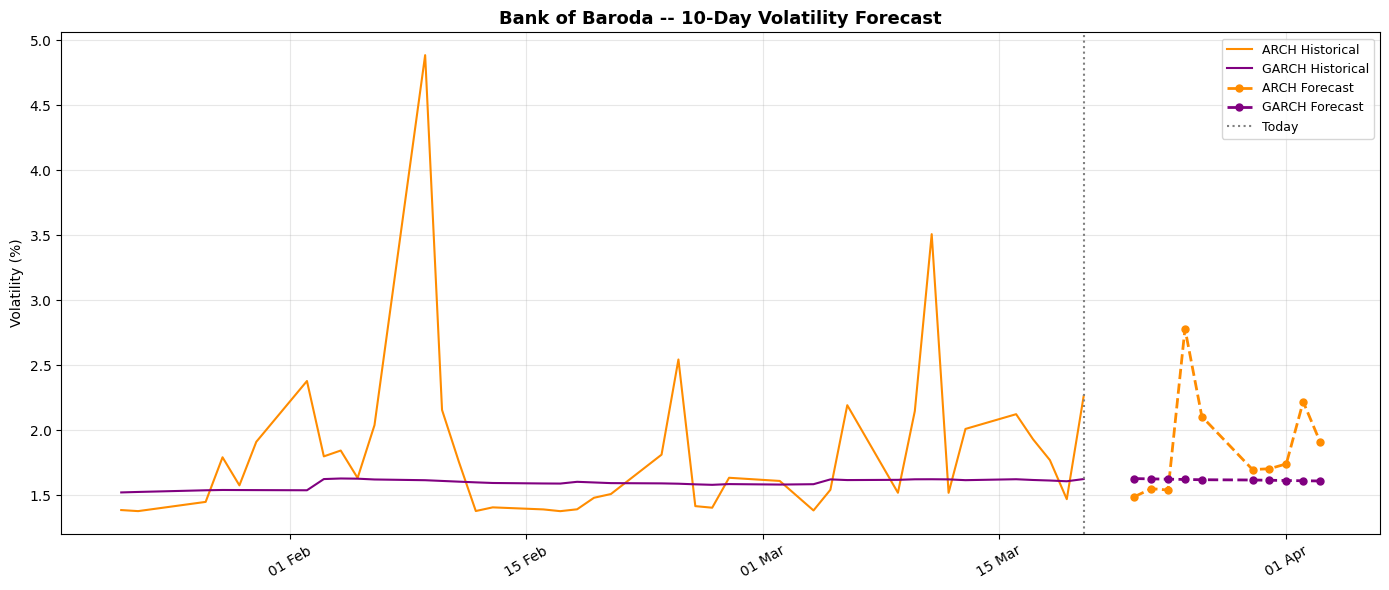

Dashed lines to the right of the grey vertical line = forecast.
GARCH smoothly reverts to its long-run level -- a key realistic property.


In [22]:
lookback = 40  # Show 40 historical days before the forecast

fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(arch_vol.iloc[-lookback:].index,  arch_vol.iloc[-lookback:].values,
        color='darkorange', linewidth=1.5, label='ARCH Historical')
ax.plot(garch_vol.iloc[-lookback:].index, garch_vol.iloc[-lookback:].values,
        color='purple', linewidth=1.5, label='GARCH Historical')

# Forecast (dashed lines with markers)
ax.plot(fc_df.index, fc_df['ARCH(5) Vol (%)'],
        color='darkorange', linewidth=2, linestyle='--', marker='o', markersize=5,
        label='ARCH Forecast')
ax.plot(fc_df.index, fc_df['GARCH(1,1) Vol (%)'],
        color='purple', linewidth=2, linestyle='--', marker='o', markersize=5,
        label='GARCH Forecast')

# Mark where forecast begins
ax.axvline(last_date, color='gray', linewidth=1.5, linestyle=':', label='Today')

ax.set_title(f'{ASSET_NAME} -- {FORECAST_DAYS}-Day Volatility Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Dashed lines to the right of the grey vertical line = forecast.')
print('GARCH smoothly reverts to its long-run level -- a key realistic property.')

---
## Step 14: Final Summary

In [ ]:
print('''
====================================================================
  ARCH vs GARCH -- PLAIN ENGLISH SUMMARY
====================================================================

WHAT WE BUILT:
  Downloaded 1 year of Bank of Baroda daily stock prices
  -> Converted to log returns
  -> Confirmed stationarity with ADF test
  -> Saw volatility clustering visually
  -> Confirmed ARCH effects statistically
  -> Fitted ARCH(5) and GARCH(1,1) models
  -> Compared them on AIC/BIC
  -> Forecasted 10-day volatility

ARCH IN ONE SENTENCE:
  "Today's volatility = how wild the past few days were."
  Short memory | spiky | needs many parameters

GARCH IN ONE SENTENCE:
  "Today's volatility = how wild recently + how volatile things have been."
  Long memory | smooth | just 3 parameters | industry standard

KEY GARCH(1,1) PARAMETERS:
  omega (w) -> baseline variance floor
  alpha (a) -> how strongly a shock impacts next day's volatility
  beta  (b) -> how long volatility persists after a shock
  a + b close to 1 -> high persistence (typical for Indian stocks)

